# 04 — Interpretação dos Resultados

Interpretação dos coeficientes via exp(b) e diagnóstico do modelo.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/dataset_vendedores.csv")
coefs = pd.read_csv("../outputs/coeficientes_negbin.csv", index_col=0)
with open("../outputs/metricas_modelos.json") as f:
    metricas = json.load(f)

print(f"Dataset: {len(df):,} vendedores")
print(f"Coeficientes: {len(coefs)}")

Dataset: 1,754 vendedores
Coeficientes: 6


## 1. Interpretação via exp(b)

Com offset log(n_reviews), os coeficientes modelam a **taxa** de reviews negativos.
exp(b) indica o fator multiplicativo sobre a taxa para cada unidade de aumento em X.

In [2]:
coefs["pct_change"] = (coefs["exp_coef"] - 1) * 100

interp = coefs.drop(["const"], errors="ignore").copy()
interp = interp[interp["p_value"] < 0.05].sort_values("exp_coef", ascending=False)

print("=== Efeitos significativos ===")
fmt = "{:<40s} {:>8s} {:>8s} {:>10s} {:>10s}"
print(fmt.format("Variavel", "Coef", "exp(b)", "Efeito %", "p-valor"))
print("-" * 80)
for idx, row in interp.iterrows():
    sinal = "+" if row["pct_change"] > 0 else ""
    print(f"{idx:<40s} {row['coef']:>8.4f} {row['exp_coef']:>8.4f} {sinal}{row['pct_change']:>9.2f}% {row['p_value']:>10.2e}")

=== Efeitos significativos ===
Variavel                                     Coef   exp(b)   Efeito %    p-valor
--------------------------------------------------------------------------------
cat_group_telephony                        0.3051   1.3568 +    35.68%   2.06e-04
cat_group_bed_bath_table                   0.2706   1.3108 +    31.08%   3.03e-06
cat_group_furniture_decor                  0.2387   1.2696 +    26.96%   2.99e-05
atraso_medio                               0.0436   1.0445 +     4.45%   9.16e-25
frete_medio                                0.0054   1.0054 +     0.54%   3.65e-10


## 2. Visualização dos coeficientes

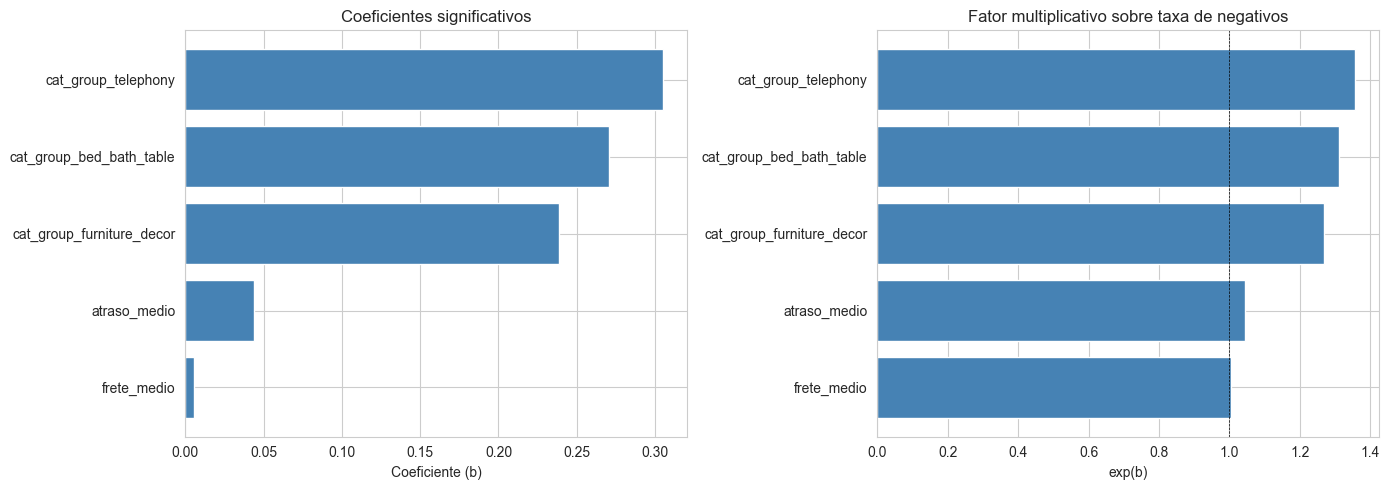

In [3]:
interp_sorted = interp.sort_values("coef")

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(interp_sorted)*0.7)))

colors = ["steelblue" if c > 0 else "coral" for c in interp_sorted["coef"]]
axes[0].barh(range(len(interp_sorted)), interp_sorted["coef"], color=colors, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.5)
axes[0].set_xlabel("Coeficiente (b)")
axes[0].set_title("Coeficientes significativos")
axes[0].set_yticks(range(len(interp_sorted)))
axes[0].set_yticklabels(interp_sorted.index)
vmax0 = interp_sorted["coef"].max()
axes[0].set_xlim(0, vmax0 * 1.3)
for j, v in enumerate(interp_sorted["coef"]):
    axes[0].text(v + vmax0 * 0.02, j, f"{v:.4f}", va="center", ha="left", fontsize=8)

colors2 = ["steelblue" if c > 1 else "coral" for c in interp_sorted["exp_coef"]]
axes[1].barh(range(len(interp_sorted)), interp_sorted["exp_coef"], color=colors2, edgecolor="white")
axes[1].axvline(1, color="black", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("exp(b)")
axes[1].set_title("Fator multiplicativo sobre taxa de negativos")
axes[1].set_yticks(range(len(interp_sorted)))
axes[1].set_yticklabels(interp_sorted.index)
vmax1 = interp_sorted["exp_coef"].max()
axes[1].set_xlim(0, vmax1 * 1.12)
for j, v in enumerate(interp_sorted["exp_coef"]):
    axes[1].text(v + vmax1 * 0.01, j, f"{v:.3f}", va="center", ha="left", fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/interp_coeficientes.png", bbox_inches="tight", dpi=120)
plt.show()

## 3. Tabela comparativa

In [4]:
print("=== Comparacao final ===")
fmt = "{:<20s} {:>15s} {:>15s} {:>15s}"
print(fmt.format("", "Poisson", "BN Completo", "BN Reduzido"))
print("-" * 68)
for key, label in [("aic", "AIC"), ("bic", "BIC"), ("llf", "Log-Likelihood"), ("deviance", "Deviance")]:
    vp = metricas["poisson"][key]
    vc = metricas["negbin_completo"][key]
    vr = metricas["negbin_reduzido"][key]
    print(f"{label:<20s} {vp:>15.2f} {vc:>15.2f} {vr:>15.2f}")

ct = metricas["cameron_trivedi"]
print(f"\nCameron-Trivedi: alpha={ct['alpha']:.4f}, t={ct['t']:.2f}, p={ct['p_value']:.2e}")
lr = metricas["lr_test"]
print(f"LR test: stat={lr['statistic']:.2f}, p={lr['p_value']:.2e}")

=== Comparacao final ===
                             Poisson     BN Completo     BN Reduzido
--------------------------------------------------------------------
AIC                          7488.67         6996.66         6982.97
BIC                          7647.29         7155.28         7015.78
Log-Likelihood              -3715.34        -3469.33        -3485.48
Deviance                     3002.79         1831.60         1863.90

Cameron-Trivedi: alpha=0.0449, t=6.29, p=3.88e-10
LR test: stat=492.01, p=5.21e-109


## 4. Diagnóstico dos resíduos

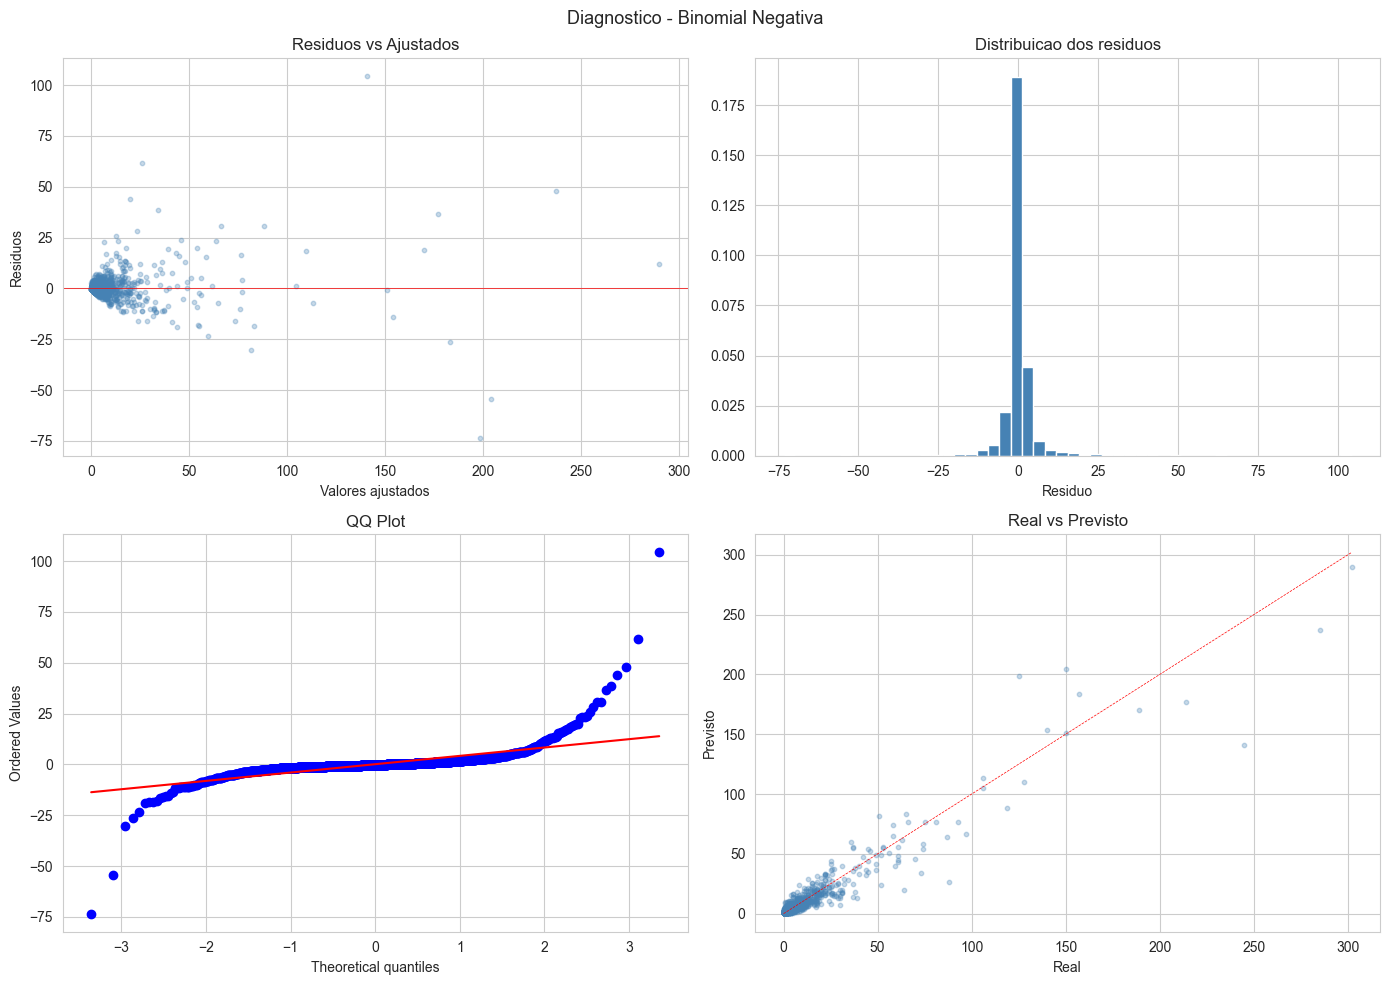

In [5]:
# Reestimar modelo
cat_counts = df["categoria_principal"].value_counts()
cats_keep = cat_counts[cat_counts >= 30].index.tolist()
df["cat_group"] = df["categoria_principal"].where(df["categoria_principal"].isin(cats_keep), "other")

st_counts = df["seller_state"].value_counts()
st_keep = st_counts[st_counts >= 30].index.tolist()
df["state_group"] = df["seller_state"].where(df["seller_state"].isin(st_keep), "other")

df["log_n_reviews"] = np.log(df["n_reviews"])
df_model = df[["n_negative", "log_n_reviews", "atraso_medio", "ticket_medio",
               "frete_medio", "peso_medio", "cat_group", "state_group"]].copy()
df_model = pd.get_dummies(df_model, columns=["cat_group", "state_group"], drop_first=True, dtype=int)

y = df_model["n_negative"]
offset = df_model["log_n_reviews"]
X = df_model.drop(columns=["n_negative", "log_n_reviews"])
X = sm.add_constant(X)

alpha_mm = metricas["negbin_completo"]["alpha"]
nb = sm.GLM(y, X, family=sm.families.NegativeBinomial(alpha=alpha_mm), offset=offset).fit()
y_pred = nb.fittedvalues
residuos = y - y_pred

mask = np.isfinite(residuos) & np.isfinite(y_pred)
res_plot = residuos[mask]
pred_plot = y_pred[mask]
y_plot = y[mask]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(pred_plot, res_plot, alpha=0.3, s=10, color="steelblue")
axes[0,0].axhline(0, color="red", linewidth=0.5)
axes[0,0].set_xlabel("Valores ajustados")
axes[0,0].set_ylabel("Residuos")
axes[0,0].set_title("Residuos vs Ajustados")

axes[0,1].hist(res_plot, bins=50, color="steelblue", edgecolor="white", density=True)
axes[0,1].set_xlabel("Residuo")
axes[0,1].set_title("Distribuicao dos residuos")

stats.probplot(res_plot, plot=axes[1,0])
axes[1,0].set_title("QQ Plot")

axes[1,1].scatter(y_plot, pred_plot, alpha=0.3, s=10, color="steelblue")
lim = max(y_plot.max(), pred_plot.max())
axes[1,1].plot([0, lim], [0, lim], "r--", linewidth=0.5)
axes[1,1].set_xlabel("Real")
axes[1,1].set_ylabel("Previsto")
axes[1,1].set_title("Real vs Previsto")

plt.suptitle("Diagnostico - Binomial Negativa", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/interp_diagnostico_residuos.png", bbox_inches="tight")
plt.show()

## 5. Resumo

In [6]:
print("=" * 60)
print("RESUMO DOS RESULTADOS")
print("=" * 60)

print(f"\n1. SOBREDISPERSAO")
print(f"   Var/Media = {y.var()/y.mean():.2f}")
print(f"   Cameron-Trivedi p = {metricas['cameron_trivedi']['p_value']:.2e}")

print(f"\n2. MODELO SELECIONADO: Binomial Negativa")
print(f"   AIC: {metricas['negbin_reduzido']['aic']:.2f}")
print(f"   BIC: {metricas['negbin_reduzido']['bic']:.2f}")
print(f"   Pearson chi2/df: {metricas['negbin_reduzido']['pearson_chi2_df']:.4f}")

print(f"\n3. DETERMINANTES DA INSATISFACAO")
for idx, row in interp.iterrows():
    direcao = "AUMENTA" if row["pct_change"] > 0 else "REDUZ"
    print(f"   {idx}: {direcao} {abs(row['pct_change']):.1f}% a taxa de reviews negativos")

RESUMO DOS RESULTADOS

1. SOBREDISPERSAO
   Var/Media = 52.90
   Cameron-Trivedi p = 3.88e-10

2. MODELO SELECIONADO: Binomial Negativa
   AIC: 6982.97
   BIC: 7015.78
   Pearson chi2/df: 1.0609

3. DETERMINANTES DA INSATISFACAO
   cat_group_telephony: AUMENTA 35.7% a taxa de reviews negativos
   cat_group_bed_bath_table: AUMENTA 31.1% a taxa de reviews negativos
   cat_group_furniture_decor: AUMENTA 27.0% a taxa de reviews negativos
   atraso_medio: AUMENTA 4.5% a taxa de reviews negativos
   frete_medio: AUMENTA 0.5% a taxa de reviews negativos


## 6. Exportar plots em GIF (para divulgação)

Converte os PNGs principais do estudo em GIFs curtos com efeito de zoom para facilitar o uso em postagens.

In [ ]:
from pathlib import Path
from PIL import Image

OUT = Path("../outputs")
OUT.mkdir(parents=True, exist_ok=True)

def make_zoom_gif(input_png: Path, output_gif: Path, n_frames: int = 20, zoom_max: float = 1.10, fps: int = 10):
    """Gera GIF curto com zoom suave ida-volta para chamar atencao no feed."""
    base = Image.open(input_png).convert("RGB")
    w, h = base.size

    # Sequencia de zoom (ida e volta)
    half = n_frames // 2
    zoom_in = [1 + (zoom_max - 1) * (i / max(half - 1, 1)) for i in range(half)]
    zoom_out = list(reversed(zoom_in))
    zoom_seq = zoom_in + zoom_out

    frames = []
    for z in zoom_seq:
        zw, zh = int(w / z), int(h / z)
        left = (w - zw) // 2
        top = (h - zh) // 2
        crop = base.crop((left, top, left + zw, top + zh)).resize((w, h), Image.Resampling.LANCZOS)
        frames.append(crop)

    duration = int(1000 / fps)
    frames[0].save(
        output_gif,
        save_all=True,
        append_images=frames[1:],
        duration=duration,
        loop=0,
        optimize=True,
    )

plots_para_gif = [
    "eda_distribuicao_negativos.png",
    "eda_negativos_vs_atraso.png",
    "eda_negativos_por_categoria.png",
    "eda_negativos_por_estado.png",
    "eda_correlacao.png",
    "interp_coeficientes.png",
    "interp_diagnostico_residuos.png",
    "modelo_performance_taxa.png",
]

gifs_gerados = []
for plot in plots_para_gif:
    png_path = OUT / plot
    if png_path.exists():
        gif_name = png_path.stem + ".gif"
        gif_path = OUT / gif_name
        make_zoom_gif(png_path, gif_path)
        gifs_gerados.append(gif_name)
    else:
        print(f"[AVISO] Nao encontrado: {png_path}")

print(f"GIFs gerados: {len(gifs_gerados)}")
for g in gifs_gerados:
    print(f" - ../outputs/{g}")